# Retail Sales Data Cleaning & Summary Analysis

**Technical Club FLUX — Round 2 Recruitment Task**

**Name:** Geetanshi Diyawar  |  **Domain:** Data Science

---

## Objective

Clean, filter, and analyze a retail sales dataset to extract meaningful business insights. The analysis covers:

- Inspecting and cleaning the dataset (missing values, duplicates, data types)
- Filtering transactions by category and time period
- Computing key business metrics (total revenue, average price, top-selling items)
- Visualizing monthly sales trends and category performance
- Summarizing actionable observations

## 1. Setup

Importing the libraries required for data manipulation, analysis, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")
# Global plot styling — applied to every chart for consistency
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

Libraries imported successfully!


## 2. Data Loading & Initial Inspection

Loading the dataset and performing a first-pass inspection of its structure, columns, and data types.

In [2]:
df = pd.read_csv("retail_store_sales.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [4]:
#column listing
list(df.columns)

['Transaction ID',
 'Customer ID',
 'Category',
 'Item',
 'Price Per Unit',
 'Quantity',
 'Total Spent',
 'Payment Method',
 'Location',
 'Transaction Date',
 'Discount Applied']

In [5]:
# Shape of the dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 12575
Number of columns: 11


**Dataset Size**

The dataset contains 12,575 retail transactions and 11 attributes describing each transaction.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


**Initial observations from `info()`:**

The dataset contains **12,575 records and 11 columns**. 
The output also shows that some columns contain missing values. In particular, `Item`, `Price Per Unit`, `Quantity`, `Total Spent`, and `Discount Applied` have incomplete records. These missing values will be addressed during the data-cleaning stage.

The `Transaction Date` column is currently stored as a string and will later be converted into a proper datetime format to enable time-based analysis.

In [7]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


**Statistical summary (numeric columns):**

| Metric | Price Per Unit | Quantity | Total Spent |
|---|---|---|---|
| Mean | ~23.37 | ~5.54 | ~129.65 |
| Min | 5.00 | 1 | 5.00 |
| Max | 41.00 | 10 | 410.00 |


-  The `count` values are below 12,575 because of the missing entries noted above. Standard deviations indicate meaningful spread in all three columns, so imputation should respect category-level structure rather than using a global value.


## 3. Missing Values & Duplicate Check

Quantifying missing data per column and checking for fully duplicated rows.

In [8]:
# Missing values: count + percentage, sorted by severity
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64


In [9]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

In [10]:
missing_summary

,Missing Values,Missing Percentage
Transaction ID,0,0.00
Customer ID,0,0.00
Category,0,0.00
Item,1213,9.65
Price Per Unit,609,4.84
Quantity,604,4.80
Total Spent,604,4.80
Payment Method,0,0.00
Location,0,0.00
Transaction Date,0,0.00


In [11]:
missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values("Missing Values",ascending=False)

In [12]:
missing_summary

,Missing Values,Missing Percentage
Discount Applied,4199,33.39
Item,1213,9.65
Price Per Unit,609,4.84
Quantity,604,4.80
Total Spent,604,4.80


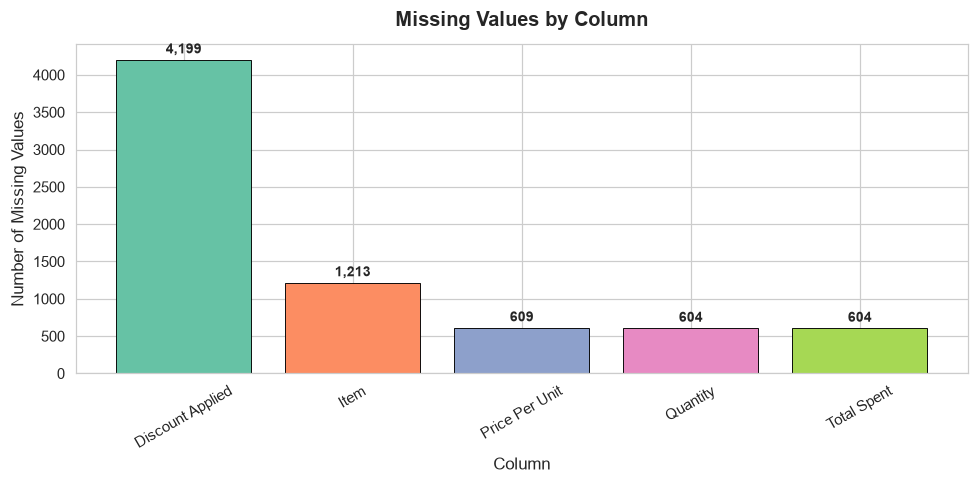

In [13]:
# Visualizing missing-value counts
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(
    missing_summary.index,
    missing_summary["Missing Values"],
    color=sns.color_palette("Set2", len(missing_summary)),
    edgecolor="black",
    linewidth=0.6,
)
ax.set_title("Missing Values by Column", pad=12)
ax.set_xlabel("Column")
ax.set_ylabel("Number of Missing Values")
ax.tick_params(axis="x", rotation=30)

# Annotate each bar with its count
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, h + 50,
        f"{int(h):,}", ha="center", va="bottom", fontsize=9, fontweight="bold",
    )

plt.tight_layout()
plt.show()

In [14]:
# Duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


**Findings:**

- `Discount Applied` has the most missing values (~33.4%) — expected, since many transactions simply have no discount.
- `Item` is missing in ~9.65% of rows.
- `Price Per Unit`, `Quantity`, and `Total Spent` are each missing in under 5% of rows.
- No fully duplicated rows were found.

## 4. Data Cleaning

Applying targeted cleaning operations:
1. Convert `Transaction Date` to `datetime`.
2. Fill `Discount Applied` missing values with `False`.
3. Fill `Item` missing values with `"Unknown Item"`.
4. Impute `Price Per Unit` and `Quantity` using the **median within each category**.
5. Recompute `Total Spent` as `Price Per Unit × Quantity` where missing.

In [15]:
# 1. Transaction Date -> datetime
df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce"
)

print("Transaction Date data type:", df["Transaction Date"].dtype)

Transaction Date data type: datetime64[us]


In [16]:
print(
    "Invalid transaction dates:",
    df["Transaction Date"].isnull().sum()
)

Invalid transaction dates: 0


In [17]:
# 2. Discount Applied: NaN -> False (no discount recorded)
df["Discount Applied"].value_counts(dropna=False)

Discount Applied
True     4219
NaN      4199
False    4157
Name: count, dtype: int64

In [18]:
df["Discount Applied"] = df["Discount Applied"].fillna(False)

print(df["Discount Applied"].value_counts())

Discount Applied
False    8356
True     4219
Name: count, dtype: int64


In [19]:
# 3. Item: NaN -> 'Unknown Item'
df["Item"] = df["Item"].fillna("Unknown Item")

In [20]:
print("Missing Item values:", df["Item"].isnull().sum())

Missing Item values: 0


In [21]:
# 4. Price Per Unit: impute with median price within each Category
category_median_price = df.groupby("Category")["Price Per Unit"].transform("median")

In [22]:
df["Price Per Unit"].fillna(category_median_price)

0        18.5
1        29.0
2        21.5
3        27.5
4        12.5
         ... 
12570    38.0
12571     6.5
12572    14.0
12573    14.0
12574    17.0
Name: Price Per Unit, Length: 12575, dtype: float64

In [23]:
df["Price Per Unit"] = df["Price Per Unit"].fillna(category_median_price)

In [24]:
print("Missing Price Per Unit:", df["Price Per Unit"].isnull().sum())

Missing Price Per Unit: 0


In [25]:
# 5. Quantity: impute with median quantity within each Category
quantity_median_price = df.groupby("Category")["Quantity"].transform("median")

In [26]:
df["Quantity"].fillna(quantity_median_price)

0        10.0
1         9.0
2         2.0
3         9.0
4         7.0
         ... 
12570     4.0
12571     9.0
12572    10.0
12573     6.0
12574     3.0
Name: Quantity, Length: 12575, dtype: float64

In [27]:
df["Quantity"] = df["Quantity"].fillna(quantity_median_price)

In [28]:
print("Missing Quantity:", df["Quantity"].isnull().sum())

Missing Quantity: 0


In [29]:
# 6. Total Spent: recompute where missing, using Price Per Unit * Quantity
df["Total Spent"] = df["Total Spent"].fillna(
    df["Price Per Unit"] * df["Quantity"]
)

In [30]:
print("Missing Total Spent:", df["Total Spent"].isnull().sum())

Missing Total Spent: 0


In [31]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64


In [32]:
# Final verification — no missing values should remain
df.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

In [33]:
df.head(20)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,Unknown Item,23.0,10.0,200.0,Credit Card,Online,2023-11-30,False
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
7,TXN_1372952,CUST_21,Furniture,Unknown Item,33.5,6.0,201.0,Digital Wallet,In-store,2024-04-02,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False


**Cleaning summary:** All missing values have been resolved. The dataset is now ready for analysis.

| Step | Strategy |
|---|---|
| `Transaction Date` | Parsed to `datetime` |
| `Discount Applied` | `NaN → False` (no discount) |
| `Item` | `NaN → "Unknown Item"` |
| `Price Per Unit` | Category-wise median imputation |
| `Quantity` | Category-wise median imputation |
| `Total Spent` | Recomputed as `Price × Quantity` where missing |
| Duplicates | None found |

In [34]:
# Preserve a clean copy for downstream analysis
clean_df = df.copy()

print("Now, Clean dataset created successfully!")
print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])

Now, Clean dataset created successfully!
Rows: 12575
Columns: 11


In [35]:
clean_df["Category"].value_counts()

Category
Furniture                             1591
Electric household essentials         1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64

In [36]:
clean_df["Transaction Date"].min(), clean_df["Transaction Date"].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2025-01-18 00:00:00'))

## 5. Data Filtering

Demonstrating two common filtering patterns: by category and by time period.

In [37]:
# Filter 1: only 'Food' category transactions
food_sales = clean_df[
    clean_df["Category"] == "Food"].copy()

In [38]:
print("Food transactions:", len(food_sales))

Food transactions: 1588


In [39]:
food_sales.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
12,TXN_5874772,CUST_23,Food,Item_2_FOOD,6.5,7.0,45.5,Cash,Online,2023-09-09,True
23,TXN_3314099,CUST_04,Food,Item_10_FOOD,18.5,1.0,18.5,Cash,Online,2023-09-30,False
28,TXN_1598860,CUST_08,Food,Item_14_FOOD,24.5,10.0,245.0,Cash,In-store,2022-10-23,True
30,TXN_5444504,CUST_05,Food,Item_11_FOOD,20.0,10.0,200.0,Digital Wallet,Online,2022-04-26,False
32,TXN_1543244,CUST_20,Food,Unknown Item,23.0,8.0,196.0,Credit Card,Online,2024-10-25,True
36,TXN_9065245,CUST_02,Food,Item_23_FOOD,38.0,2.0,76.0,Digital Wallet,In-store,2024-03-10,False
44,TXN_4740738,CUST_25,Food,Item_3_FOOD,8.0,1.0,8.0,Digital Wallet,In-store,2022-04-19,False
45,TXN_9587232,CUST_20,Food,Item_12_FOOD,21.5,5.0,107.5,Digital Wallet,Online,2023-02-28,True


In [40]:
# Filter 2: transactions from 2024
sales_2024 = clean_df[
    clean_df["Transaction Date"].dt.year == 2024].copy()


In [41]:
sales_2024.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
7,TXN_1372952,CUST_21,Furniture,Unknown Item,33.5,6.0,201.0,Digital Wallet,In-store,2024-04-02,True
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False
10,TXN_8776416,CUST_22,Butchers,Item_3_BUT,8.0,9.0,72.0,Cash,In-store,2024-12-14,True
16,TXN_7563311,CUST_23,Patisserie,Item_17_PAT,29.0,8.0,232.0,Cash,Online,2024-11-16,True
20,TXN_9939063,CUST_14,Beverages,Item_7_BEV,14.0,9.0,126.0,Digital Wallet,In-store,2024-01-14,False
27,TXN_1599706,CUST_14,Furniture,Item_25_FUR,41.0,10.0,410.0,Credit Card,In-store,2024-03-24,True
32,TXN_1543244,CUST_20,Food,Unknown Item,23.0,8.0,196.0,Credit Card,Online,2024-10-25,True
33,TXN_1494700,CUST_12,Electric household essentials,Item_21_EHE,35.0,9.0,315.0,Credit Card,In-store,2024-03-07,False
35,TXN_6398436,CUST_15,Beverages,Item_25_BEV,41.0,7.0,287.0,Credit Card,In-store,2024-06-03,True


In [42]:
print("Transactions in 2024:", len(sales_2024))

Transactions in 2024: 4241


## 6. Key Business Metrics

Computing the headline numbers: total revenue, average item price, and the top 5 best-selling items by quantity sold.

In [43]:
# Total sales revenue across all cleaned transactions
total_revenue = clean_df["Total Spent"].sum()

print(f"Total Sales Revenue: {total_revenue:,.2f}")

Total Sales Revenue: 1,635,694.50


In [44]:
# Average item price
average_price = clean_df["Price Per Unit"].mean()

print(f"Average Item Price: {average_price:,.2f}")

Average Item Price: 23.38


In [45]:
# Top 5 best-selling items by total quantity sold.
# 'Unknown Item' is excluded from this ranking because it represents missing item names,
# not an actual product — including it would mislead the reader.
top_5_items = (
    clean_df[clean_df["Item"] != "Unknown Item"]
    .groupby("Item")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

In [46]:
top_5_items

Item
Item_2_BEV      676.0
Item_16_MILK    627.0
Item_25_FUR     616.0
Item_19_MILK    589.0
Item_5_FUR      581.0
Name: Quantity, dtype: float64

## 7. Visualizations

Three views of the cleaned data: monthly revenue trend, top-selling items, and revenue by category.

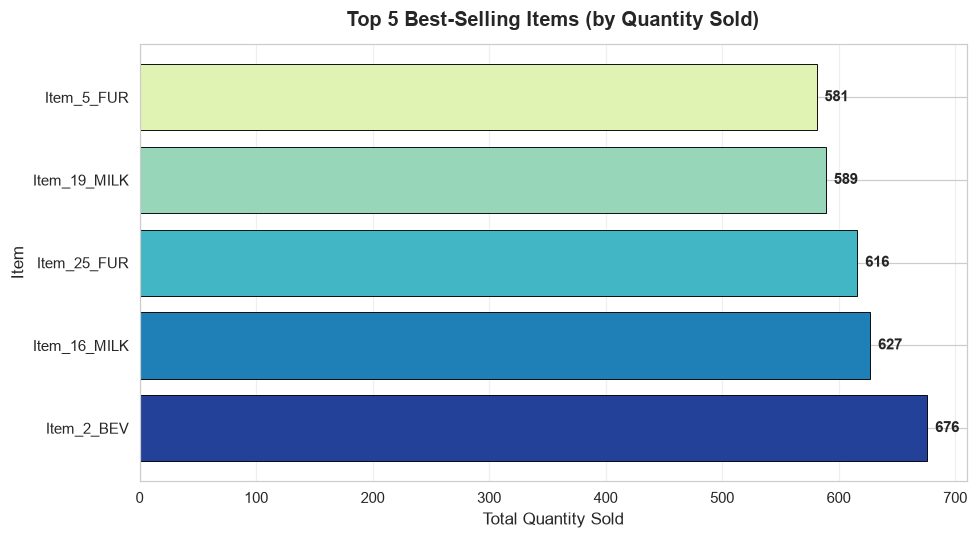

In [47]:
# --- Top 5 best-selling items ---
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    top_5_items.index,
    top_5_items.values,
    color=sns.color_palette("YlGnBu_r", len(top_5_items)),
    edgecolor="black", linewidth=0.6,
)

# Value labels at the end of each bar
for bar in bars:
    w = bar.get_width()
    ax.text(
        w + max(top_5_items.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(w):,}", va="center", fontsize=10, fontweight="bold",
    )

ax.set_title("Top 5 Best-Selling Items (by Quantity Sold)", pad=12)
ax.set_xlabel("Total Quantity Sold")
ax.set_ylabel("Item")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# --- Monthly sales trend ---
clean_df["Month"] = clean_df["Transaction Date"].dt.to_period("M")
monthly_sales = (
    clean_df.groupby("Month")["Total Spent"].sum() )

In [49]:
print(pd.concat([monthly_sales.head(),monthly_sales.tail()]))

Month
2022-01    56198.5
2022-02    46239.0
2022-03    43193.0
2022-04    42577.5
2022-05    42066.5
2024-09    43873.0
2024-10    45077.5
2024-11    45982.0
2024-12    50662.0
2025-01    26967.5
Freq: M, Name: Total Spent, dtype: float64


In [50]:
best_month, best_month_sales = monthly_sales.idxmax(), monthly_sales.max()
worst_month, worst_month_sales = monthly_sales.idxmin(), monthly_sales.min()

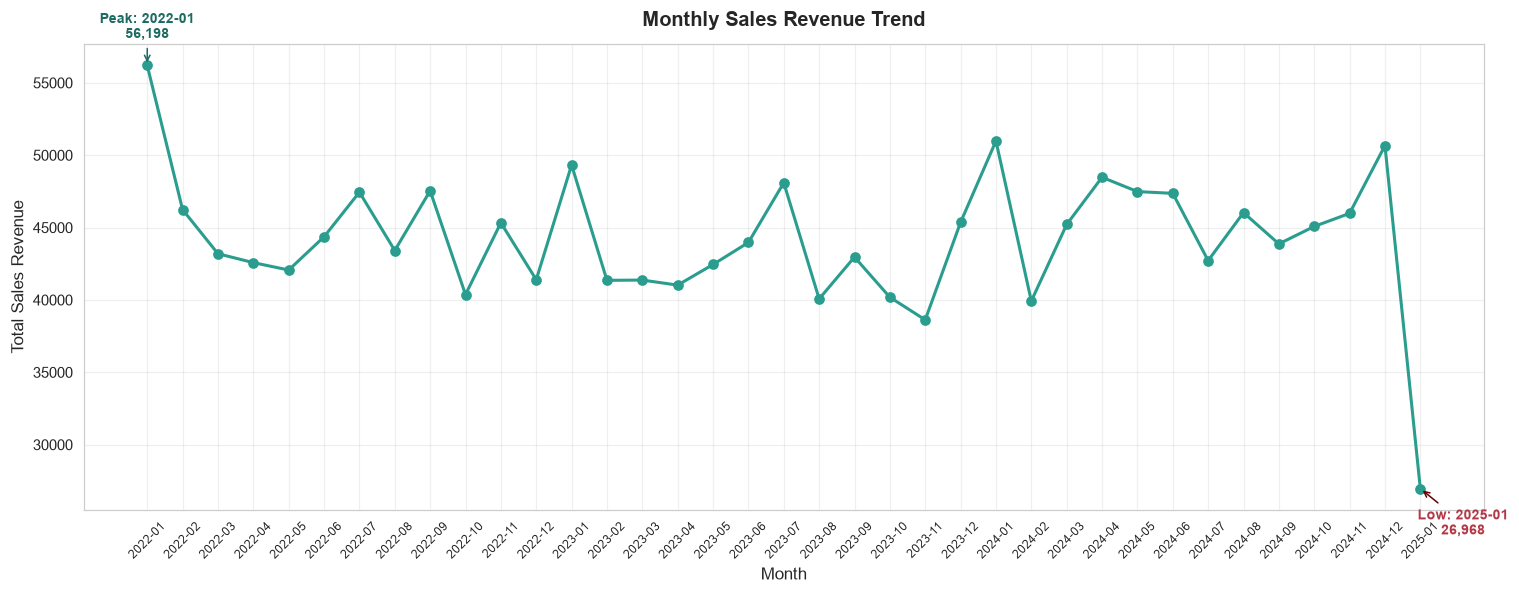

In [51]:
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o", linewidth=2, color="#2a9d8f", markersize=6,
)

# Annotate the peak and the trough
ax.annotate(
    f"Peak: {best_month}\n{best_month_sales:,.0f}",
    xy=(str(best_month), best_month_sales),
    xytext=(0, 18), textcoords="offset points",
    ha="center", fontsize=9, fontweight="bold", color="#1d6b62",
    arrowprops=dict(arrowstyle="->", color="#1d6b62", lw=1),
)
ax.annotate(
    f"Low: {worst_month}\n{worst_month_sales:,.0f}",
    xy=(str(worst_month), worst_month_sales),
    xytext=(28, -30), textcoords="offset points",
    ha="center", fontsize=9, fontweight="bold", color="#b23a48",
    arrowprops=dict(arrowstyle="->", color="#660000", lw=1),
)

ax.set_title("Monthly Sales Revenue Trend", pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales Revenue")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

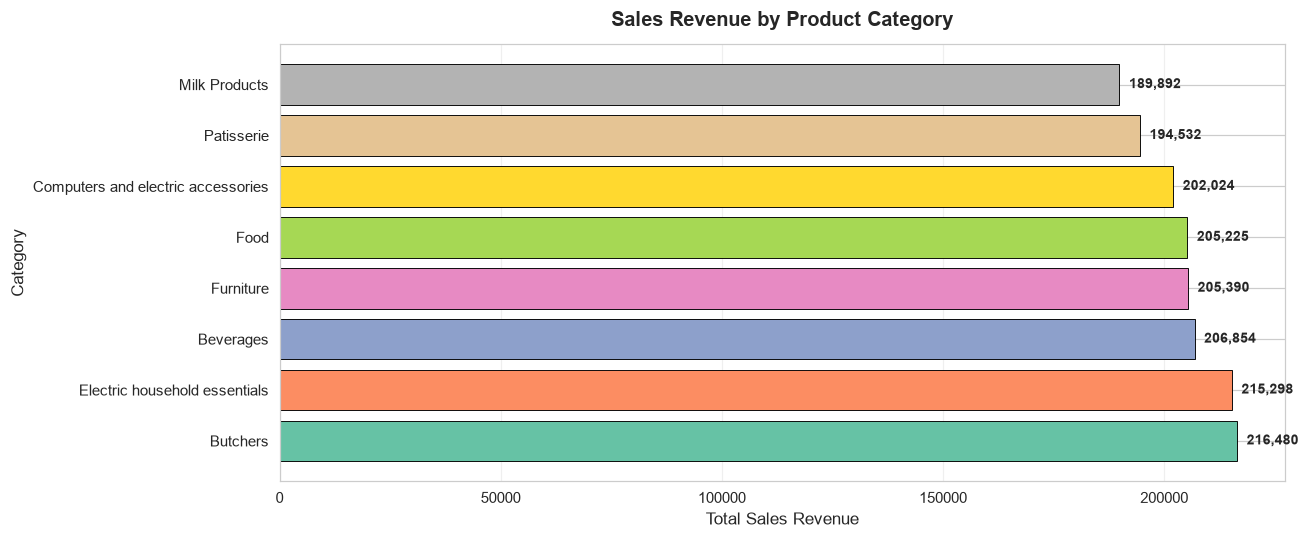

In [52]:
# --- Sales revenue by product category ---
category_sales = (
    clean_df.groupby("Category")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    category_sales.index,
    category_sales.values,
    color=sns.color_palette("Set2", len(category_sales)),
    edgecolor="black", linewidth=0.6,
)

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + max(category_sales.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{w:,.0f}", va="center", fontsize=9, fontweight="bold",
    )

ax.set_title("Sales Revenue by Product Category", pad=12)
ax.set_xlabel("Total Sales Revenue")
ax.set_ylabel("Category")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Key Observations

Based on the cleaned dataset and the analysis above:

1. **Dataset scope**: 12,575 retail transactions across 11 attributes, with no duplicate rows.
2. **Cleaning outcome**: All missing values were resolved using category-aware median imputation (for `Price Per Unit` and `Quantity`), recomputed values (for `Total Spent`), and sensible defaults (`False` for `Discount Applied`, `"Unknown Item"` for `Item`).
3. **Total revenue**: The cleaned dataset records approximately **1,635,694** in total sales.
4. **Average item price**: ~23.38 currency units.
5. **Top-selling items**: After excluding `Unknown Item` (which represents missing item names, not a real product), the top 5 items by quantity sold are shown in the chart above.
6. **Seasonality**: Monthly revenue peaks around **January 2022** and dips around **January 2025** — useful inputs for inventory and promotion planning.
7. **Category performance**: **Butchers** is the top revenue-generating category, while **Milk Products** is the lowest. The spread between categories is relatively narrow, suggesting a balanced product mix.
